# Evaluation of Optimized schedulers

In [1]:
from pathlib import Path
import sys
# Project root = folder that contains Data/ (and preprocessor/, forecast_models/)
ROOT = Path.cwd() if (Path.cwd() / "Data").exists() else Path.cwd().parent
if not (ROOT / "Data").exists():
    raise FileNotFoundError("Data folder not found. Run notebook from project root or forecast_implementation.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from energy_components import *
from typing import Optional, Tuple
import pandas as pd
from helper import draw
import itertools
import cvxpy as cp
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
import gurobipy
import gymnasium as gym
from Schedulers import *
from Optimization import check_results,count_switch_ons,feasibility_summary
from Optimization.feasibility_layer_LP import feasibility_layer_LP
from Optimization.feasibility_layer_RL import feasibility_layer_RL
from forecast_implementation.forecast_helper import format_for_csv

In [2]:
SAVE = True

### **Input Prices**

In [3]:
# Input data
gas_price = 0.11 # EUR/Kwh
grid_price = 0.3 # EUR/Kwh
feed_in_price = .065 # EUR/Kwh
swtch_cst = 10

### **Input Components**

In [4]:
# Input components
pv = PV(name="PV",capacity=110)

boiler = Boiler(name="Boiler",
                capacity=150,
                rated_input_heat=167)

chp = CHP(name="CHP",capacity=43.33,
            rated_output_elec=13,
            rated_output_heat=26)

battery = Battery(name="Battery",capacity=60,
                    soc_elec=30,
                    max_charge_rate_elec=30,
                    max_discharge_rate_elec=30,
                    eta_charge_elec=.99,
                    eta_discharge_elec=.99)

buffer = Buffer(name="Buffer", capacity=100,
                 soc_heat=50,
                 eta_charge_heat=.99,
                 eta_discharge_heat=.99)

ee = ElectricHeatingElement(name="ee", capacity=30, conv_efficiency=.99)

components = {
    "boiler": boiler,
    "chp": chp,
    "ee": ee,
    "pv": pv,
    "buffer":buffer,
    "battery":battery,
}

### **Input Data**

In [5]:
DATA_DIR = ROOT / "Data"
gas_demand = pd.read_csv(DATA_DIR / "heat_forecast_for_optimizer.csv", index_col=0, parse_dates=True)
elec_demand = pd.read_csv(DATA_DIR / "electricity_forecast_for_optimizer.csv", index_col=0, parse_dates=True)
pv_generation = pd.read_csv(DATA_DIR / "pv_forecast_for_optimizer.csv", index_col=0, parse_dates=True)
pv_generation["forecast"] = pv_generation["forecast"].clip(lower=0.0)

In [6]:
pv_generation

,actual,forecast
datetime,,
2024-10-01 01:00:00,0.0,0.000000
2024-10-01 02:00:00,0.0,0.000000
2024-10-01 03:00:00,0.0,0.057685
2024-10-01 04:00:00,0.0,0.057685
2024-10-01 05:00:00,0.0,0.000000
...,...,...
2024-12-30 20:00:00,0.0,0.000000
2024-12-30 21:00:00,0.0,0.000000
2024-12-30 22:00:00,0.0,0.000000


In [7]:
evaluation_index = gas_demand.index

In [8]:
elec_demand

,actual,forecast
datetime,,
2024-10-01 01:00:00,8.959999,7.340394
2024-10-01 02:00:00,8.937005,7.541122
2024-10-01 03:00:00,9.353842,6.656133
2024-10-01 04:00:00,9.436158,10.232496
2024-10-01 05:00:00,8.900000,12.114661
...,...,...
2024-12-30 20:00:00,11.766339,9.875137
2024-12-30 21:00:00,12.040000,9.687879
2024-12-30 22:00:00,12.110000,10.116842


In [9]:
elec_real = elec_demand["actual"]
heat_real = gas_demand["actual"]
pv_real = pv_generation["actual"]
elec_forecast = elec_demand["forecast"]
heat_forecast = gas_demand["forecast"]
pv_forecast_series = pv_generation["forecast"]

**Baseline Evaluation**

In [10]:
dt = DigitalTwin(components)
dt.create_rule(name="Baseline")(Baseline_edited)
rule_name = "Baseline"
components = components


baseline_load, baseline_gas_price, baseline_elec_price = dt.simulate_twin(rule_name,components,evaluation_index,elec_demand = elec_real, gas_demand = heat_real,
                                                                           pv_generated =pv_real,gas_price = gas_price,grid_price = grid_price,feed_in_price = feed_in_price)

In [11]:
baseline_gas_cost = baseline_gas_price["gas_price_total"].sum()
print("total gas cost: ", baseline_gas_cost)
baseline_elec_cost = baseline_elec_price["elec_price_total"].sum()
print("total electricity cost: ", baseline_elec_cost)
# baseline switching cost
switch_baseline =pd.DataFrame(baseline_load)[["boiler_in_total","chp_in"]]
switch_baseline.index = evaluation_index
total_cost3a = baseline_gas_cost + baseline_elec_cost
switch_cost = count_switch_ons(switch_baseline,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)

total gas cost:  26653.6
total electricity cost:  5807.9
switch cost:  1700
total cost:  34161.5


In [12]:
# on forecast
dt = DigitalTwin(components)
dt.create_rule(name="Baseline")(Baseline_edited)
rule_name = "Baseline"
components = components


baseline_loadf, baseline_gas_pricef, baseline_elec_pricef = dt.simulate_twin(rule_name,components,evaluation_index,elec_demand = elec_forecast, gas_demand = heat_forecast,
                                                                           pv_generated =pv_forecast_series,gas_price = gas_price,grid_price = grid_price,feed_in_price = feed_in_price)

In [13]:
baseline_gas_cost = baseline_gas_pricef["gas_price_total"].sum()
print("total gas cost: ", baseline_gas_cost)
baseline_elec_cost = baseline_elec_pricef["elec_price_total"].sum()
print("total electricity cost: ", baseline_elec_cost)
# baseline switching cost
switch_baseline =pd.DataFrame(baseline_load)[["boiler_in_total","chp_in"]]
switch_baseline.index = evaluation_index
total_cost3a = baseline_gas_cost + baseline_elec_cost
switch_cost = count_switch_ons(switch_baseline,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)

total gas cost:  26419.92
total electricity cost:  5421.39
switch cost:  1700
total cost:  33541.31


**24 LP with switch costs**

In [14]:
step_24_switch_LP = run_sliding_24h_forecast(date_time_series=evaluation_index,
                             frequency=60,
                             components=components,
                             lp_optimizer=optimize_24h_with_switching_cost,
                             elec_demand=elec_forecast,
                             gas_demand=heat_forecast,
                             pv_generated=pv_forecast_series,
                             switch_cost=swtch_cst,
                             feed_in_price=feed_in_price,
                             gas_price=gas_price,
                             grid_price=grid_price,
                             )

Running 24h block 1/91 starting at 2024-10-01 01:00:00
Running 24h block 2/91 starting at 2024-10-02 01:00:00
Running 24h block 3/91 starting at 2024-10-03 01:00:00
Running 24h block 4/91 starting at 2024-10-04 01:00:00
Running 24h block 5/91 starting at 2024-10-05 01:00:00
Running 24h block 6/91 starting at 2024-10-06 01:00:00
Running 24h block 7/91 starting at 2024-10-07 01:00:00
Running 24h block 8/91 starting at 2024-10-08 01:00:00
Running 24h block 9/91 starting at 2024-10-09 01:00:00
Running 24h block 10/91 starting at 2024-10-10 01:00:00
Running 24h block 11/91 starting at 2024-10-11 01:00:00
Running 24h block 12/91 starting at 2024-10-12 01:00:00
Running 24h block 13/91 starting at 2024-10-13 01:00:00
Running 24h block 14/91 starting at 2024-10-14 01:00:00
Running 24h block 15/91 starting at 2024-10-15 01:00:00
Running 24h block 16/91 starting at 2024-10-16 01:00:00
Running 24h block 17/91 starting at 2024-10-17 01:00:00
Running 24h block 18/91 starting at 2024-10-18 01:00:00
R

In [15]:
step_24_switch_LP.status.value_counts()

status
optimal    2184
Name: count, dtype: int64

In [16]:
# cost before feasibility check
step_24_gas_cost = step_24_switch_LP["gas_price_total"].sum()
print("total gas cost: ", step_24_gas_cost)
step_24_elec_cost = step_24_switch_LP["elec_price_total"].sum()
print("total electricity cost: ", step_24_elec_cost)
# baseline switching cost
switch_24_step=step_24_switch_LP[["boiler_in_total","chp_in"]]
switch_24_step.index = evaluation_index
total_cost3a = step_24_gas_cost + step_24_elec_cost
switch_cost = count_switch_ons(switch_baseline,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)

total gas cost:  26300.570008222207
total electricity cost:  4953.369141240349
switch cost:  1700
total cost:  32953.93914946256


In [17]:
#index to exclude
exclude_index = pd.DatetimeIndex([])
check_infeasible_index = step_24_switch_LP[step_24_switch_LP.status!="optimal"].index
if check_infeasible_index.shape[0] == 0:
    exclude_index = exclude_index
else:
    exclude_index = exclude_index.append(check_infeasible_index).unique()
exclude_index

DatetimeIndex([], dtype='datetime64[ns]', freq=None)

In [18]:
pv_forecast_series[exclude_index]

Series([], Name: forecast, dtype: float64)

In [19]:
def run_feasibility_over_plan(
    step_24_switch_LP,
    elec_real,
    heat_real,
    pv_real,
    components,
    lambda_res=100.0,
    soc_elec_init=30.0,
    soc_heat_init=50.0,
):
    """
    Chained feasibility LP:
    - Step 0 starts from (soc_elec_init, soc_heat_init)
    - Each subsequent step uses the previous LP step's soc_elec/soc_heat
      via plan["previous_soc"] / plan["previous_soc_buff"].
    """
    rows = []

    T = len(step_24_switch_LP)
    soc_elec = float(soc_elec_init)
    soc_heat = float(soc_heat_init)

    for t in range(T):
        # Take the t-th plan row and attach previous SOC for this LP step
        plan = step_24_switch_LP.iloc[t].copy()
        plan["previous_soc"] = soc_elec
        plan["previous_soc_buff"] = soc_heat

        # Call feasibility_layer_LP on a single-row DataFrame at local index 0
        out = feasibility_layer_LP(
            df=pd.DataFrame([plan]),
            elec_real=elec_real.iloc[[t]],
            heat_real=heat_real.iloc[[t]],
            pv_real=pv_real.iloc[[t]],
            components=components,
            t=0,
            lambda_res=lambda_res,
        )

        # Update SOC for the next step in the chain
        soc_elec = out["soc_elec"]
        soc_heat = out["soc_heat"]

        # Optionally keep time index
        out["t"] = t

        rows.append(out)

    return pd.DataFrame(rows)


# Use chained feasibility for the 24h LP plan
df_feasible = run_feasibility_over_plan(
    step_24_switch_LP,
    elec_real,
    heat_real,
    pv_real,
    components,
)

In [20]:
df_feasible.status.value_counts()

status
optimal       2183
infeasible       1
Name: count, dtype: int64

In [21]:
df_feasible.index = evaluation_index

In [22]:
check_infeasible_index = df_feasible[df_feasible.status!="optimal"].index
if check_infeasible_index.shape[0] == 0:
    exclude_index = exclude_index
else:
    exclude_index = exclude_index.append(check_infeasible_index).unique()
exclude_index

DatetimeIndex(['2024-12-09 10:00:00'], dtype='datetime64[ns]', freq=None)

In [23]:
df_feasible_check = pd.DataFrame(df_feasible)
df_feasible_check["elec_demand"] = elec_real.values
df_feasible_check["gas_demand"] = heat_real.values
df_feasible_check["pv_gen"] = pv_real.values

In [24]:
df_feasible_check_result = check_results(df_feasible_check,components=components,tol=1)
df_feasible_check_result.columns

Index(['heat_demand_met', 'elec_demand_met', 'batt_charge_chp_pv',
       'buff_charge_chp_boil', 'elec_to_ee_by_pv_chp_batt',
       'pv_generated_alloc', 'boiler_alloc', 'boiler_out_ratings',
       'boiler_in_out_rln', 'ee_elec_ratings', 'ee_in_out_rln',
       'batt_disch_to_de_ee', 'batt_disch_ratings', 'buff_disch_ratings',
       'buff_charge_ratings', 'batt_charge_ratings', 'chp_to_heat_buff',
       'chp_to_ele_batt_ee', 'chp_in_out_rln_heat', 'chp_in_out_rln_elec',
       'chp_out_elec_ratings', 'chp_out_heat_ratings', 'chp_threshold',
       'boiler_threshold'],
      dtype='object')

In [25]:
lp_feasible = feasibility_summary(df_feasible_check_result, tol=1)
lp_feasible

,pct,infeasible_indexes
heat_demand_met,99.954212,[2024-12-09 10:00:00]
elec_demand_met,99.954212,[2024-12-09 10:00:00]
batt_charge_chp_pv,100.000000,[]
buff_charge_chp_boil,100.000000,[]
elec_to_ee_by_pv_chp_batt,100.000000,[]
pv_generated_alloc,100.000000,[]
boiler_alloc,100.000000,[]
boiler_out_ratings,100.000000,[]
boiler_in_out_rln,100.000000,[]
ee_elec_ratings,100.000000,[]


In [26]:
lp_feasible = format_for_csv(lp_feasible,decimal_places=2)
lp_feasible.index.name = "Feasiblity check"
if SAVE:
    lp_feasible.to_csv(DATA_DIR/"lp_feasible.csv",index=True)

In [27]:
df_feasible_check.loc["2024-11-14 08:00:00",:]

boiler                     109.802901
boiler_to_buffer                  0.0
boiler_out_total           109.802901
boiler_in_total             122.24723
Grid                        56.807598
chp_out_de                        0.0
chp_out_ee                       13.0
chp_out_charge                    0.0
chp_out_heat                     26.0
chp_out_hd                       26.0
chp_out_buff                      0.0
chp_in                          43.33
chp_total_elec                   13.0
pv_out_de                    0.161412
pv_out_ee                      0.3001
pv_out_charge                     0.0
buffer_out                        0.0
total_stored_heat                 0.0
actual_stored_heat                0.0
soc_heat                          0.0
batt_out_de                       0.0
batt_out_ee                       0.0
total_battery_discharge           0.0
actual_charged_batt               0.0
soc_elec                          0.0
ee_in_elec_actual             13.3001
ee_heat     

In [28]:
print("Electricity price: ", df_feasible_check["elec_price_Grid"].sum())
print("Gas price: ", df_feasible_check["gas_price_total"].sum())
switch_cost = count_switch_ons(df_feasible_check,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("Total price: ", df_feasible_check["elec_price_Grid"].sum() + df_feasible_check["gas_price_total"].sum() + switch_cost)

Electricity price:  6795.532644304259
Gas price:  26736.143862457866
switch cost:  120
Total price:  33651.67650676212


**24 hr RL - PPO**

In [29]:
gas_elec_raw = pd.read_csv(DATA_DIR / "gas_electricity_hourly.csv", index_col=0, parse_dates=True)
pv_raw = pd.read_csv(DATA_DIR / "pv_generated_hourly.csv", index_col=0, parse_dates=True)

In [30]:
elec_all = gas_elec_raw["elecmeter"]
heat_all = gas_elec_raw["gasmeter"]
pv_all = pv_raw["Wert"]

In [31]:
import pandas as pd
import numpy as np
from pathlib import Path
from stable_baselines3 import PPO
from stable_baselines3.common.env_util import make_vec_env
from stable_baselines3.common.vec_env import DummyVecEnv
from preprocessor import get_date_splitter

splitter = get_date_splitter("electricity", config_path=ROOT / "split_config.csv")
# Use a DataFrame with same index as demand to get date slices
_ix = pd.DataFrame(index=elec_all.index)
train_df, val_df, test_df = splitter(_ix)
elec_train = elec_all.loc[train_df.index]
elec_val   = elec_all.loc[val_df.index]
elec_test  = elec_all.loc[test_df.index]
heat_train = heat_all.loc[train_df.index]
heat_val   = heat_all.loc[val_df.index]
heat_test  = heat_all.loc[test_df.index]
pv_train   = pv_all.loc[train_df.index]
pv_val     = pv_all.loc[val_df.index]
pv_test    = pv_all.loc[test_df.index]

# ==================== HYPERPARAMETER GRID  ====================
train_hours = len(elec_train)
total_ts_tune = train_hours * 50
param_grid = [
    {"learning_rate": 1e-4,  "gamma": 0.9,  "n_steps": 256},
    {"learning_rate": 3e-4,  "gamma": 0.99,  "n_steps": 1024},
    {"learning_rate": 1e-4,  "gamma": 0.995, "n_steps": 512},
    {"learning_rate": 3e-4,  "gamma": 0.995, "n_steps": 512},
]

def run_rollout(env, model, deterministic=True):
    """Roll out policy and return mean reward per step (higher = better)."""
    obs = env.reset()
    total_reward = 0.0
    n_steps = 0
    while True:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, rewards, dones, _ = env.step(action)
        total_reward += float(rewards[0])
        n_steps += 1
        if dones[0]:
            obs = env.reset()
        if n_steps >= len(elec_val):  # one full evaluation horizon
            break
    return total_reward / max(n_steps, 1)


val_scores = []
for i, params in enumerate(param_grid):
    print(f"Tuning run {i+1}/{len(param_grid)}: {params}")
    train_env = make_vec_env(
        lambda: LookAheadRLEnergyEnvSwitch(
            elec_train, heat_train, pv_train,
            components, lookahead=24,
            chp_switch_cost=swtch_cst, boiler_switch_cost=swtch_cst,
        ),
        n_envs=1,
    )
    model = PPO(
        policy="MlpPolicy",
        env=train_env,
        verbose=0,
        learning_rate=params["learning_rate"],
        gamma=params["gamma"],
        n_steps=params["n_steps"],
        batch_size=params["n_steps"],
        device="cpu",
        policy_kwargs=dict(log_std_init=0.1),
    )
    model.learn(total_timesteps=total_ts_tune)
    val_env = DummyVecEnv([lambda: LookAheadRLEnergyEnvSwitch(
        elec_val, heat_val, pv_val, components, lookahead=24,
        chp_switch_cost=swtch_cst, boiler_switch_cost=swtch_cst,
    )])
    score = run_rollout(val_env, model)
    val_scores.append(score)
    print(f"  -> val mean reward/step: {score:.4f}")
best_idx = int(np.argmax(val_scores))
best_params = param_grid[best_idx].copy()
print(f"Best params (by val reward): {best_params}")


Tuning run 1/4: {'learning_rate': 0.0001, 'gamma': 0.9, 'n_steps': 256}
  -> val mean reward/step: -115.9634
Tuning run 2/4: {'learning_rate': 0.0003, 'gamma': 0.99, 'n_steps': 1024}
  -> val mean reward/step: -114.5390
Tuning run 3/4: {'learning_rate': 0.0001, 'gamma': 0.995, 'n_steps': 512}
  -> val mean reward/step: -114.6296
Tuning run 4/4: {'learning_rate': 0.0003, 'gamma': 0.995, 'n_steps': 512}
  -> val mean reward/step: -115.8125
Best params (by val reward): {'learning_rate': 0.0003, 'gamma': 0.99, 'n_steps': 1024}


In [38]:
# ==================== TRAIN BEST ON TRAIN SET ====================
print("Training best model on train set...")
train_env_final = make_vec_env(
    lambda: LookAheadRLEnergyEnvSwitch(
        elec_train, heat_train, pv_train,
        components, lookahead=24,
        chp_switch_cost=swtch_cst, boiler_switch_cost=swtch_cst,
    ),
    n_envs=1,
)
model = PPO(
    policy="MlpPolicy",
    env=train_env_final,
    verbose=0,
    learning_rate=best_params["learning_rate"],
    gamma=best_params["gamma"],
    n_steps=best_params["n_steps"],
    batch_size=min(256, best_params["n_steps"]),
    device="cpu",
    policy_kwargs=dict(log_std_init=0.1),
)

model.learn(total_timesteps=train_hours * 500)
# ==================== EVALUATE ON TEST SET ====================
print("Evaluating on forecast values...")
eval_env = LookAheadRLEnergyEnvSwitch(
    elec_forecast, heat_forecast, pv_forecast_series,
    components, lookahead=24,
    chp_switch_cost=swtch_cst, boiler_switch_cost=swtch_cst,
)
vec_env_eval = DummyVecEnv([lambda: eval_env])
obs = vec_env_eval.reset()
rows = []
episode_reward = 0.0
episode_idx = 0
timestep = 0
n_timesteps = len(elec_forecast)
while timestep < n_timesteps:
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, dones, infos = vec_env_eval.step(action)
    r = rewards[0]
    done = dones[0]
    episode_reward += r
    row = infos[0].copy()
    for i, a in enumerate(action[0]):
        row[f"action_raw_{i}"] = float(a)
        mapped_key = f"action_01_{i}"
        row[f"action_{i}"] = float(row.get(mapped_key, 0.5 * (float(a) + 1.0)))
    row["reward"] = r
    row["timestep"] = timestep
    row["episode"] = episode_idx
    rows.append(row)
    timestep += 1
    if done:
        print(f"Test episode {episode_idx} total reward: {episode_reward:.2f}")
        episode_reward = 0.0
        episode_idx += 1
lookahead_RL_results_switch = pd.DataFrame(rows)
print(lookahead_RL_results_switch.shape)
lookahead_RL_results_switch.head()

Training best model on train set...
Evaluating on forecast values...
Test episode 0 total reward: -952.15
Test episode 1 total reward: -1028.18
Test episode 2 total reward: -1318.84
Test episode 3 total reward: -1203.69
Test episode 4 total reward: -1303.09
Test episode 5 total reward: -1304.86
Test episode 6 total reward: -834.01
Test episode 7 total reward: -1057.39
Test episode 8 total reward: -1254.94
Test episode 9 total reward: -983.39
Test episode 10 total reward: -893.06
Test episode 11 total reward: -1211.58
Test episode 12 total reward: -1248.27
Test episode 13 total reward: -678.16
Test episode 14 total reward: -381.47
Test episode 15 total reward: -466.74
Test episode 16 total reward: -841.20
Test episode 17 total reward: -2050.43
Test episode 18 total reward: -2846.94
Test episode 19 total reward: -2850.06
Test episode 20 total reward: -1881.02
Test episode 21 total reward: -1049.66
Test episode 22 total reward: -652.42
Test episode 23 total reward: -873.96
Test episode 24

,t,start_hour,episode_t,action_raw_0,action_raw_1,action_raw_2,action_raw_3,action_raw_4,action_01_0,action_01_1,...,TimeLimit.truncated,action_0,action_1,action_2,action_3,action_4,reward,timestep,episode,terminal_observation
0,0,0,0,0.096845,0.000799,0.140883,0.180790,0.032188,0.548422,0.500400,...,False,0.548422,0.500400,0.570441,0.590395,0.516094,-30.279346,0,0,NaN
1,1,0,1,0.094897,0.003495,0.138771,0.173088,0.028795,0.547448,0.501748,...,False,0.547448,0.501748,0.569385,0.586544,0.514397,-74.553070,1,0,NaN
2,2,0,2,0.094911,0.007056,0.139901,0.166664,0.027709,0.547455,0.503528,...,False,0.547455,0.503528,0.569951,0.583332,0.513855,-78.038284,2,0,NaN
3,3,0,3,0.094839,0.007412,0.139542,0.166345,0.027246,0.547419,0.503706,...,False,0.547419,0.503706,0.569771,0.583172,0.513623,-72.690041,3,0,NaN
4,4,0,4,0.094854,0.007486,0.139461,0.166273,0.027122,0.547427,0.503743,...,False,0.547427,0.503743,0.569730,0.583137,0.513561,-62.813515,4,0,NaN


In [39]:
lookahead_RL_results_switch

,t,start_hour,episode_t,action_raw_0,action_raw_1,action_raw_2,action_raw_3,action_raw_4,action_01_0,action_01_1,...,TimeLimit.truncated,action_0,action_1,action_2,action_3,action_4,reward,timestep,episode,terminal_observation
0,0,0,0,0.096845,0.000799,0.140883,0.180790,0.032188,0.548422,0.500400,...,False,0.548422,0.500400,0.570441,0.590395,0.516094,-30.279346,0,0,NaN
1,1,0,1,0.094897,0.003495,0.138771,0.173088,0.028795,0.547448,0.501748,...,False,0.547448,0.501748,0.569385,0.586544,0.514397,-74.553070,1,0,NaN
2,2,0,2,0.094911,0.007056,0.139901,0.166664,0.027709,0.547455,0.503528,...,False,0.547455,0.503528,0.569951,0.583332,0.513855,-78.038284,2,0,NaN
3,3,0,3,0.094839,0.007412,0.139542,0.166345,0.027246,0.547419,0.503706,...,False,0.547419,0.503706,0.569771,0.583172,0.513623,-72.690041,3,0,NaN
4,4,0,4,0.094854,0.007486,0.139461,0.166273,0.027122,0.547427,0.503743,...,False,0.547427,0.503743,0.569730,0.583137,0.513561,-62.813515,4,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,19,0,19,0.094877,0.007541,0.139402,0.166217,0.027020,0.547438,0.503771,...,False,0.547438,0.503771,0.569701,0.583109,0.513510,-34.489849,2179,90,NaN
2180,20,0,20,0.094877,0.007542,0.139401,0.166216,0.027018,0.547438,0.503771,...,False,0.547438,0.503771,0.569700,0.583108,0.513509,-18.161310,2180,90,NaN
2181,21,0,21,0.094877,0.007543,0.139400,0.166215,0.027016,0.547439,0.503772,...,False,0.547439,0.503772,0.569700,0.583108,0.513508,-25.467154,2181,90,NaN
2182,22,0,22,0.094877,0.007544,0.139398,0.166214,0.027014,0.547439,0.503772,...,False,0.547439,0.503772,0.569699,0.583107,0.513507,-33.833992,2182,90,NaN


In [40]:
#cost before feasibility check
print("Electricity price: ", lookahead_RL_results_switch["elec_price_Grid"].sum())
print("Gas price: ", lookahead_RL_results_switch["gas_price_total"].sum())
switch_cost = count_switch_ons(lookahead_RL_results_switch,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("Total price: ", lookahead_RL_results_switch["elec_price_Grid"].sum() + lookahead_RL_results_switch["gas_price_total"].sum() + switch_cost)

Electricity price:  6092.443644789704
Gas price:  27104.476985686575
switch cost:  20
Total price:  33216.92063047628


In [41]:
lookahead_RL_results_switch.shape

(2184, 63)

In [42]:
def run_feasibility_over_rl_plan_chained(
    rl_plan_df,
    elec_real,
    heat_real,
    pv_real,
    components,
    lambda_res=100.0,
    soc_elec_init=30.0,
    soc_heat_init=50.0,
):
    """
    Chained feasibility trajectory:
    - Step 0 starts from (soc_elec_init, soc_heat_init).
    - Each step t uses the *previous LP step's* soc as "previous_soc"/"previous_soc_buff".
    """
    results = []

    soc_elec = float(soc_elec_init)
    soc_heat = float(soc_heat_init)

    # Make sure we go through the evaluation horizon in order
    for t, (_, row) in enumerate(rl_plan_df.iterrows()):
        # Build a row that carries previous SOC for this LP step
        row_lp = row.copy()
        row_lp["previous_soc"] = soc_elec
        row_lp["previous_soc_buff"] = soc_heat

        out = feasibility_layer_RL(
            row=row_lp,
            elec_real=elec_real.iloc[t],
            heat_real=heat_real.iloc[t],
            pv_real=pv_real.iloc[t],
            components=components,
            lambda_res=lambda_res,
        )

        # Update SOC for next step in the chain
        soc_elec = out["soc_elec"]
        soc_heat = out["soc_heat"]

        # Keep time alignment metadata if you like
        out["t"] = t
        out["episode_t"] = row.get("episode_t", t)
        out["start_hour"] = row.get("start_hour", None)

        results.append(out)

    return pd.DataFrame(results)

rl_feasible_df = run_feasibility_over_rl_plan_chained(
    rl_plan_df=lookahead_RL_results_switch,
    elec_real=elec_real,
    heat_real=heat_real,
    pv_real=pv_real,
    components=components,
    lambda_res=100.0
)

In [43]:
rl_feasible_df.status.value_counts()

status
optimal    2184
Name: count, dtype: int64

In [44]:
check_infeasible_index = rl_feasible_df[rl_feasible_df.status!="optimal"].index
if check_infeasible_index.shape[0] == 0:
    exclude_index = exclude_index
else:
    exclude_index = exclude_index.append(check_infeasible_index).unique()
exclude_index

DatetimeIndex(['2024-12-09 10:00:00'], dtype='datetime64[ns]', freq=None)

In [45]:
rl_feasible_df

,boiler,boiler_to_buffer,boiler_out_total,boiler_in_total,Grid,chp_out_de,chp_out_heat,chp_out_hd,chp_in,chp_total_elec,...,elec_price_Grid,gas_price_chp,gas_price_total,elec_price_total,status,solver_used,solver_verbose,t,episode_t,start_hour
0,0.000000,50.505051,50.505051,56.228956,0.000000,10.651797,21.303594,21.303594,35.503258,10.651797,...,0.000000,3.905358,10.090544,0.000000,optimal,GUROBI,,0,0,0
1,4.802156,25.197844,30.000000,33.400000,0.000000,10.646732,21.293464,21.293464,35.486377,10.646732,...,0.000000,3.903501,7.577501,0.000000,optimal,GUROBI,,1,1,0
2,9.691481,20.308519,30.000000,33.400000,0.000000,10.646769,21.293537,21.293537,35.486499,10.646769,...,0.000000,3.903515,7.577515,0.000000,optimal,GUROBI,,2,2,0
3,15.700457,14.299543,30.000000,33.400000,0.000000,10.646581,21.293163,21.293163,35.485875,10.646581,...,0.000000,3.903446,7.577446,0.000000,optimal,GUROBI,,3,3,0
4,20.810754,9.189246,30.000000,33.400000,0.000000,10.646620,21.293240,21.293240,35.486004,10.646620,...,0.000000,3.903460,7.577460,0.000000,optimal,GUROBI,,4,4,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2179,30.651842,20.685306,51.337148,57.155359,31.119660,10.646679,21.293358,21.293358,35.486200,10.646679,...,9.335898,3.903482,10.190571,9.335898,optimal,GUROBI,,2179,19,0
2180,37.692972,13.644048,51.337020,57.155216,31.393320,10.646680,21.293359,21.293359,35.486202,10.646680,...,9.417996,3.903482,10.190556,9.417996,optimal,GUROBI,,2180,20,0
2181,13.674108,37.662790,51.336898,57.155079,31.463320,10.646680,21.293360,21.293360,35.486204,10.646680,...,9.438996,3.903482,10.190541,9.438996,optimal,GUROBI,,2181,21,0
2182,0.000000,51.336779,51.336779,57.154947,23.290388,10.646681,21.293362,21.293362,35.486206,10.646681,...,6.987116,3.903483,10.190527,6.987116,optimal,GUROBI,,2182,22,0


In [46]:
rl_feasible_df_check = pd.DataFrame(rl_feasible_df)
rl_feasible_df_check["elec_demand"] = elec_real.values
rl_feasible_df_check["gas_demand"] = heat_real.values
rl_feasible_df_check["pv_gen"] = pv_real.values
rl_feasible_df_check_result = check_results(rl_feasible_df_check,ignore=[3,4,5,6,12,17,18,7],components=components)
rl_feasible_df_check_result.columns

Index(['heat_demand_met', 'elec_demand_met', 'boiler_out_ratings',
       'boiler_in_out_rln', 'ee_elec_ratings', 'ee_in_out_rln',
       'batt_disch_ratings', 'buff_disch_ratings', 'buff_charge_ratings',
       'batt_charge_ratings', 'chp_in_out_rln_heat', 'chp_in_out_rln_elec',
       'chp_out_elec_ratings', 'chp_out_heat_ratings', 'chp_threshold',
       'boiler_threshold'],
      dtype='object')

In [47]:
print("Electricity price: ", rl_feasible_df_check["elec_price_Grid"].sum())
print("Gas price: ", rl_feasible_df_check["gas_price_total"].sum())
switch_cost = count_switch_ons(rl_feasible_df_check,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("Total price: ", rl_feasible_df_check["elec_price_Grid"].sum() + rl_feasible_df_check["gas_price_total"].sum()+switch_cost)

Electricity price:  9816.985891814209
Gas price:  25033.948586499617
switch cost:  390
Total price:  35240.93447831382


In [48]:
rl_feasible_df_check_result.columns

Index(['heat_demand_met', 'elec_demand_met', 'boiler_out_ratings',
       'boiler_in_out_rln', 'ee_elec_ratings', 'ee_in_out_rln',
       'batt_disch_ratings', 'buff_disch_ratings', 'buff_charge_ratings',
       'batt_charge_ratings', 'chp_in_out_rln_heat', 'chp_in_out_rln_elec',
       'chp_out_elec_ratings', 'chp_out_heat_ratings', 'chp_threshold',
       'boiler_threshold'],
      dtype='object')

In [57]:
rl_feasible = feasibility_summary(rl_feasible_df_check_result, tol=1)
rl_feasible

,pct,infeasible_indexes
heat_demand_met,100.000000,[]
elec_demand_met,40.155678,"[0, 1, 2, 3, 4, 44, 46, 47, 48, 49, 50, 51, 52..."
boiler_out_ratings,100.000000,[]
boiler_in_out_rln,100.000000,[]
ee_elec_ratings,100.000000,[]
ee_in_out_rln,100.000000,[]
batt_disch_ratings,100.000000,[]
buff_disch_ratings,100.000000,[]
buff_charge_ratings,100.000000,[]
batt_charge_ratings,100.000000,[]


In [58]:
rl_feasible_df_check_result[rl_feasible_df_check_result.elec_demand_met>1]

,heat_demand_met,elec_demand_met,boiler_out_ratings,boiler_in_out_rln,ee_elec_ratings,ee_in_out_rln,batt_disch_ratings,buff_disch_ratings,buff_charge_ratings,batt_charge_ratings,chp_in_out_rln_heat,chp_in_out_rln_elec,chp_out_elec_ratings,chp_out_heat_ratings,chp_threshold,boiler_threshold


In [60]:
rl_feasible = format_for_csv(rl_feasible,decimal_places=2)
rl_feasible.index.name = "Feasiblity check"
if SAVE:
    rl_feasible.drop("infeasible_indexes",axis=1).to_csv(DATA_DIR/"rl_feasible.csv",index=True)

In [52]:
# cost comparisions
# baseline
print("==Baseline==")
baseline_gas_price_df = pd.DataFrame(baseline_gas_price,index=evaluation_index)
baseline_gas_price_df[~baseline_gas_price_df.index.isin(exclude_index)] 
baseline_gas_cost = baseline_gas_price_df["gas_price_total"].sum()
print("total gas cost: ", baseline_gas_cost)

baseline_elec_price_df = pd.DataFrame(baseline_elec_price,index=evaluation_index)
baseline_elec_price_df[~baseline_elec_price_df.index.isin(exclude_index)] 

baseline_elec_cost = baseline_elec_price_df["elec_price_total"].sum()
print("total electricity cost: ", baseline_elec_cost)

# baseline switching cost
switch_baseline =pd.DataFrame(baseline_load)[["boiler_in_total","chp_in"]]
switch_baseline.index = evaluation_index
switch_baseline[~switch_baseline.index.isin(exclude_index)]

total_cost3a = baseline_gas_cost + baseline_elec_cost
switch_cost = count_switch_ons(switch_baseline,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)


# baseline
print("==Baseline with forecast data==")
baseline_gas_cost = baseline_gas_pricef["gas_price_total"].sum()
print("total gas cost: ", baseline_gas_cost)
baseline_elec_cost = baseline_elec_pricef["elec_price_total"].sum()
print("total electricity cost: ", baseline_elec_cost)
# baseline switching cost
switch_baseline =pd.DataFrame(baseline_load)[["boiler_in_total","chp_in"]]
switch_baseline.index = evaluation_index
total_cost3a = baseline_gas_cost + baseline_elec_cost
switch_cost = count_switch_ons(switch_baseline,columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)


print("==24h LP Before Feasibility Check==")
# cost before feasibility check
step_24_switch_LP.index = evaluation_index
step_24_gas_cost = step_24_switch_LP[~step_24_switch_LP.index.isin(exclude_index)]["gas_price_total"].sum()
print("total gas cost: ", step_24_gas_cost)
step_24_elec_cost = step_24_switch_LP[~step_24_switch_LP.index.isin(exclude_index)]["elec_price_total"].sum()
print("total electricity cost: ", step_24_elec_cost)
# baseline switching cost
switch_24_step=step_24_switch_LP[["boiler_in_total","chp_in"]]
switch_24_step.index = evaluation_index
total_cost3a = step_24_gas_cost + step_24_elec_cost
switch_cost = count_switch_ons(switch_24_step[~switch_24_step.index.isin(exclude_index)],columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("total cost: ", total_cost3a + switch_cost)

print("==24h LP After Feasibility Check==")
df_feasible_check.index = evaluation_index
print("Electricity price: ", df_feasible_check[~df_feasible_check.index.isin(exclude_index)]["elec_price_Grid"].sum())
print("Gas price: ", df_feasible_check[~df_feasible_check.index.isin(exclude_index)]["gas_price_total"].sum())
switch_cost = count_switch_ons(df_feasible_check[~df_feasible_check.index.isin(exclude_index)],columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("Total price: ", df_feasible_check[~df_feasible_check.index.isin(exclude_index)]["elec_price_Grid"].sum() + df_feasible_check[~df_feasible_check.index.isin(exclude_index)]["gas_price_total"].sum() + switch_cost)

print("==24h RL Before Feasibility Check==")
#cost before feasibility check
lookahead_RL_results_switch.index = evaluation_index
print("Electricity price: ", lookahead_RL_results_switch[~lookahead_RL_results_switch.index.isin(exclude_index)]["elec_price_Grid"].sum())
print("Gas price: ", lookahead_RL_results_switch[~lookahead_RL_results_switch.index.isin(exclude_index)]["gas_price_total"].sum())
switch_cost = count_switch_ons(lookahead_RL_results_switch[~lookahead_RL_results_switch.index.isin(exclude_index)],columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("Total price: ", lookahead_RL_results_switch[~lookahead_RL_results_switch.index.isin(exclude_index)]["elec_price_Grid"].sum() + lookahead_RL_results_switch[~lookahead_RL_results_switch.index.isin(exclude_index)]["gas_price_total"].sum() + switch_cost)


print("==24h RL After Feasibility Check==")
rl_feasible_df_check.index = evaluation_index
print("Electricity price: ", rl_feasible_df_check[~rl_feasible_df_check.index.isin(exclude_index)]["elec_price_Grid"].sum())
print("Gas price: ", rl_feasible_df_check[~rl_feasible_df_check.index.isin(exclude_index)]["gas_price_total"].sum())
switch_cost = count_switch_ons(rl_feasible_df_check[~rl_feasible_df_check.index.isin(exclude_index)],columns=["boiler_in_total","chp_in"]).sum()*swtch_cst
print("switch cost: ", switch_cost)
print("Total price: ", rl_feasible_df_check[~rl_feasible_df_check.index.isin(exclude_index)]["elec_price_Grid"].sum() + rl_feasible_df_check[~rl_feasible_df_check.index.isin(exclude_index)]["gas_price_total"].sum()+switch_cost)


==Baseline==
total gas cost:  26653.6
total electricity cost:  5807.9
switch cost:  1700
total cost:  34161.5
==Baseline with forecast data==
total gas cost:  26419.92
total electricity cost:  5421.39
switch cost:  1700
total cost:  33541.31
==24h LP Before Feasibility Check==
total gas cost:  26279.669778831747
total electricity cost:  4931.402599711647
switch cost:  150
total cost:  31361.072378543395
==24h LP After Feasibility Check==
Electricity price:  6795.532644304259
Gas price:  26736.143862457866
switch cost:  100
Total price:  33631.67650676212
==24h RL Before Feasibility Check==
Electricity price:  6069.773747769841
Gas price:  27088.221431220696
switch cost:  20
Total price:  33177.99517899054
==24h RL After Feasibility Check==
Electricity price:  9782.072153323046
Gas price:  25012.652953067038
switch cost:  390
Total price:  35184.725106390084


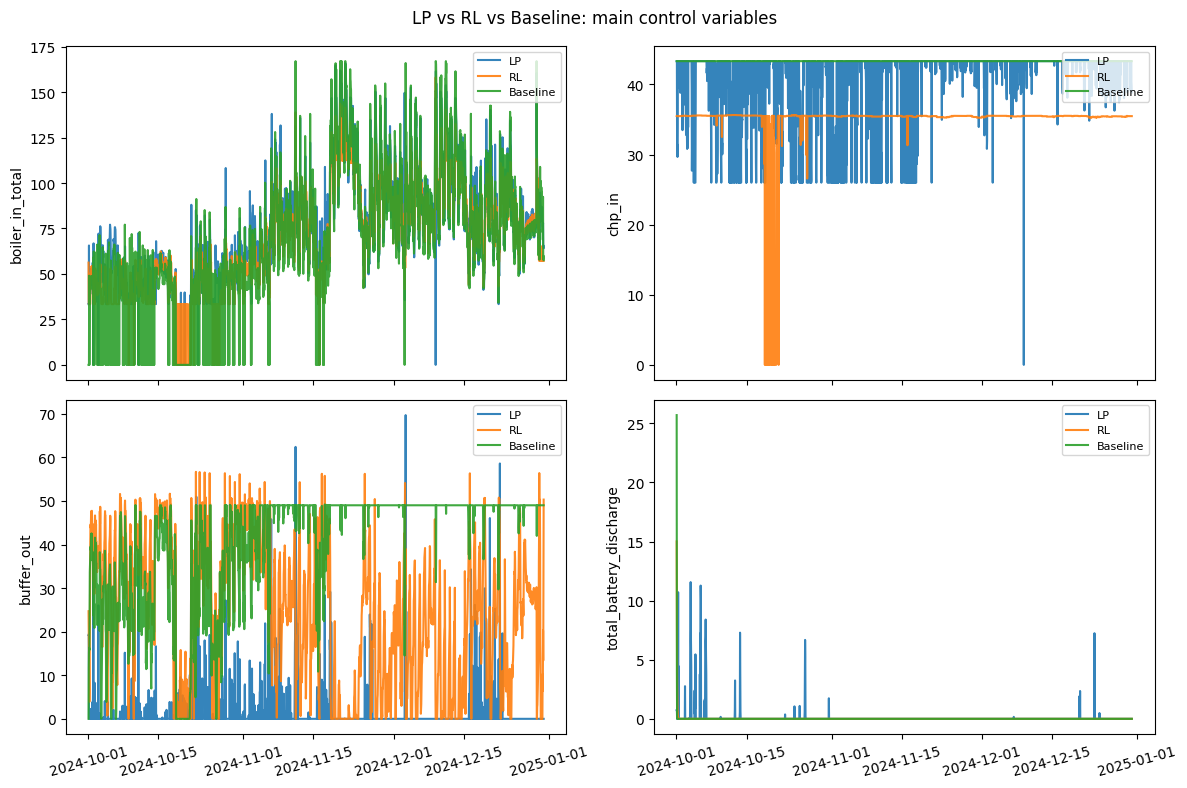

In [53]:
import matplotlib.pyplot as plt
cols = ["boiler_in_total", "chp_in", "buffer_out", "total_battery_discharge"]
# Ensure same index/length for alignment (use test index if needed)
lp = df_feasible_check[cols].copy()
rl = rl_feasible_df_check[cols].copy()
baseline = pd.DataFrame(baseline_load)[cols].copy()
# Align by position if indices differ
n = min(len(lp), len(rl), len(baseline))
lp, rl, baseline = lp.iloc[:n], rl.iloc[:n], baseline.iloc[:n]
x = lp.index if isinstance(lp.index, pd.DatetimeIndex) else np.arange(n)
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for ax, col in zip(axes.flat, cols):
    ax.plot(x, lp[col], label="LP", alpha=0.9)
    ax.plot(x, rl[col], label="RL", alpha=0.9)
    ax.plot(x, baseline[col], label="Baseline", alpha=0.9)
    ax.set_ylabel(col)
    ax.legend(loc="upper right", fontsize=8)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("LP vs RL vs Baseline: main control variables", fontsize=12)
plt.tight_layout()
plt.show()